# Baseline Classifier: Telecom Fault Classification

This notebook builds a classical ML baseline using **TF-IDF + Logistic Regression**.

Goal:
- Input: `raw_log + alarm_type + kpi_summary`
- Output: `fault_category`
- Metrics: accuracy, precision, recall, F1-score, confusion matrix


## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib


## 2. Load Dataset

In [2]:
DATA_PATH = "../data/processed/telecom_fault_dataset_model_ready.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (4000, 23)


,Unnamed: 0,incident_id,timestamp,network_element,region,raw_log,alarm_type,kpi_summary,packet_loss_percent,latency_ms,...,handover_failure_rate,prb_utilization,sinr_db,fault_category,root_cause,severity,resolution_steps,source_dataset,log_length,fault_description
0,0,INC_000001,2024-03-02 22:20:00,eNodeB_9741,Mumbai-West,- 1120266925 2005.07.01 R25-M1-N2-C:J10-U01 20...,ECC Memory Correction,"packet_loss=2.17%, latency=130.72ms, call_drop...",2.17,130.72,...,0.57,66.47,17.94,Memory/Cache Error,Processor cache parity fault,High,Review ECC counters and node health; escalate ...,Loghub-BGL,149,Raw Log: - 1120266925 2005.07.01 R25-M1-N2-C:J...
1,1,INC_000002,2024-03-06 04:20:00,AMF_5916,Gurugram-Sector-44,BLOCK* NameSystem.delete: blk_3280859030919654...,Missing Block Mapping,"packet_loss=3.63%, latency=62.71ms, call_drop_...",3.63,62.71,...,5.84,50.11,11.70,Configuration Error,Incorrect or missing network mapping metadata,High,Audit recent configuration changes and rollbac...,Loghub-HDFS,96,Raw Log: BLOCK* NameSystem.delete: blk_3280859...
2,2,INC_000003,2024-03-01 08:48:00,gNodeB_2833,Hyderabad-HITEC-City,- 1120259941 2005.07.01 R25-M1-N2-C:J08-U01 20...,Memory Parity Alarm,"packet_loss=2.2%, latency=105.66ms, call_drop_...",2.20,105.66,...,2.92,50.80,18.63,Memory/Cache Error,Correctable memory or cache parity error,High,"Monitor repeated parity errors, check memory d...",Loghub-BGL,149,Raw Log: - 1120259941 2005.07.01 R25-M1-N2-C:J...
3,3,INC_000004,2024-03-07 16:30:00,gNodeB_7671,Chennai-OMR,Receiving block blk_3598226258881465924 src: /...,Block Transfer Latency,"packet_loss=4.21%, latency=138.93ms, call_drop...",4.21,138.93,...,3.52,71.62,14.99,Transport Degradation,Intermittent degradation in node-to-node data ...,High,Monitor transfer delay and escalate if degrada...,Loghub-HDFS,94,Raw Log: Receiving block blk_35982262588814659...
4,4,INC_000005,2024-03-03 18:00:00,UPF_9177,Pune-Hinjewadi,BLOCK* NameSystem.delete: blk_-438534717113603...,Configuration Consistency Alarm,"packet_loss=3.74%, latency=77.99ms, call_drop_...",3.74,77.99,...,5.73,82.98,17.14,Configuration Error,Incorrect or missing network mapping metadata,High,Check replication policy and restore missing m...,Loghub-HDFS,96,Raw Log: BLOCK* NameSystem.delete: blk_-438534...


## 3. Check Fault Category Distribution

This helps us understand whether the dataset is balanced or imbalanced.

In [3]:
df["fault_category"].value_counts()

fault_category
Transport Degradation    1243
Application Crash        1075
Normal                    525
Memory/Cache Error        429
Backhaul Issue            342
Configuration Error       250
Core Network Issue         81
Interference               51
Hardware Failure            3
Power Outage                1
Name: count, dtype: int64

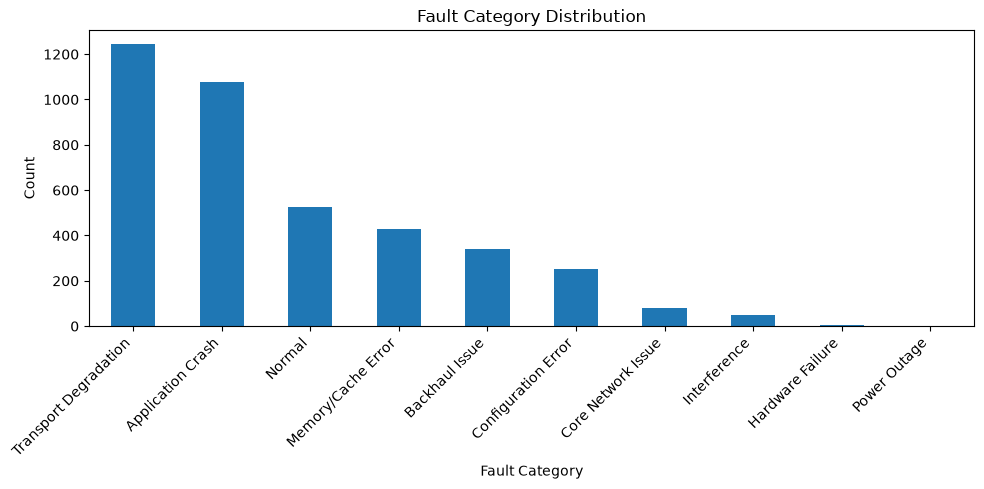

In [4]:
df["fault_category"].value_counts().plot(kind="bar", figsize=(10, 5))
plt.title("Fault Category Distribution")
plt.xlabel("Fault Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 4
. Train-Test Split

We use stratification so each fault category is represented in train and test sets as much as possible.

In [5]:
X = df["fault_description"] 
y = df["fault_category"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)



print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 3200
Testing rows: 800


## 6. Build Baseline Model

The model has two parts:

1. **TF-IDF Vectorizer**: Converts text into numerical features.
2. **Logistic Regression**: Performs multi-class classification.

In [6]:
baseline_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=10000,
            ngram_range=(1, 2),
            stop_words="english"
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        )
    )
])

baseline_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",10000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it 

## 7. Train the Model

In [7]:
baseline_model.fit(X_train, y_train)
print("Baseline model training completed.")

Baseline model training completed.


## 8. Evaluate the Model

In [8]:
y_pred = baseline_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Baseline Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

Baseline Accuracy: 0.9975

Classification Report:

                       precision    recall  f1-score   support

    Application Crash       1.00      1.00      1.00       200
       Backhaul Issue       1.00      1.00      1.00        74
  Configuration Error       1.00      1.00      1.00        45
   Core Network Issue       1.00      1.00      1.00        12
         Interference       1.00      1.00      1.00        14
   Memory/Cache Error       1.00      0.99      0.99        87
               Normal       0.99      1.00      1.00       117
         Power Outage       0.00      0.00      0.00         1
Transport Degradation       1.00      1.00      1.00       250

             accuracy                           1.00       800
            macro avg       0.89      0.89      0.89       800
         weighted avg       1.00      1.00      1.00       800



## 9. Confusion Matrix

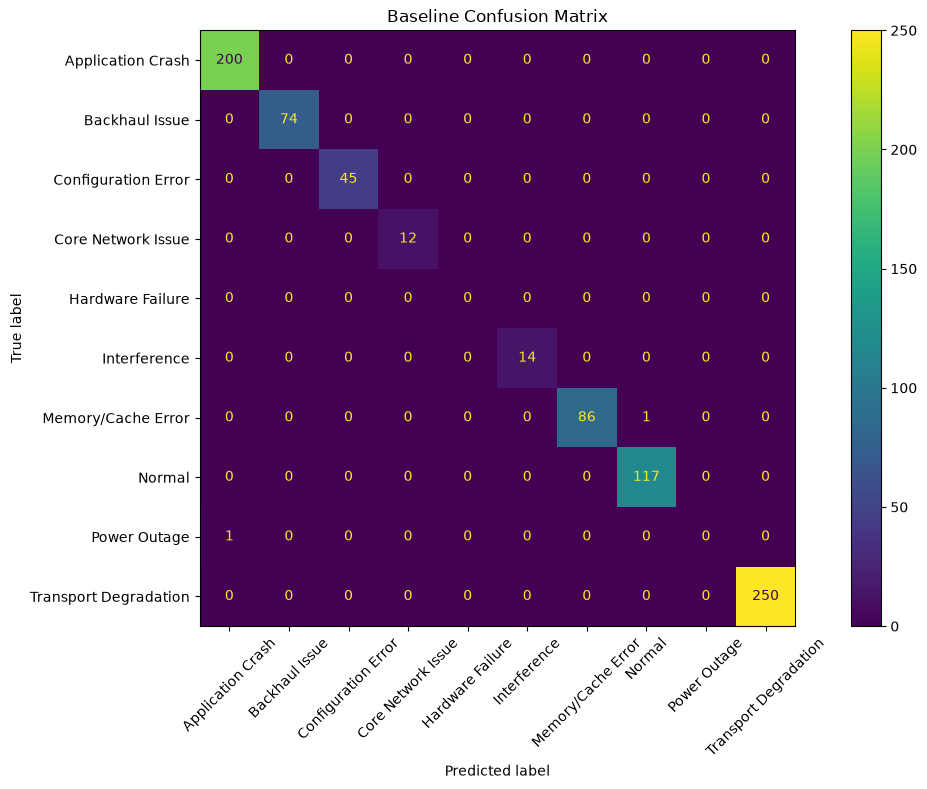

In [9]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(12, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Baseline Confusion Matrix")
plt.tight_layout()
plt.show()

## 10. Test on a Custom Example

In [10]:
sample_log = (
    "Raw Log: PacketResponder 1 for block blk_38865049064139660 terminating "
    "Alarm Type: Backhaul Packet Loss Alarm "
    "KPI Summary: packet_loss=16.95%, latency=155ms, call_drop_rate=4.65%, throughput=9.46Mbps"
)

prediction = baseline_model.predict([sample_log])[0]
prediction

'Backhaul Issue'

## 11. Save Model and Report

In [11]:
MODEL_DIR = Path("../models/baseline")
REPORT_DIR = Path("../reports")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(baseline_model, MODEL_DIR / "tfidf_logreg_baseline.joblib")

report = classification_report(y_test, y_pred, zero_division=0)

with open(REPORT_DIR / "baseline_results.txt", "w", encoding="utf-8") as f:
    f.write(f"Baseline Accuracy: {accuracy}\n\n")
    f.write("Classification Report:\n")
    f.write(report)

print("Saved model to:", MODEL_DIR / "tfidf_logreg_baseline.joblib")
print("Saved report to:", REPORT_DIR / "baseline_results.txt")

Saved model to: ..\models\baseline\tfidf_logreg_baseline.joblib
Saved report to: ..\reports\baseline_results.txt


## Summary

This baseline gives us a comparison point before LoRA fine-tuning.

The classifier predicts only `fault_category`. The LoRA model will later generate:

- Fault category
- Root cause
- Severity
- Resolution steps
